# BT4221 Project Group 4 — Validate Cleaning and Feature Engineering Agent Notebook

**Note:** This notebook performs cleaning validation and feature engineernig with LLM-driven agents using `train_parquet.parquet` and `test_parquet.parquet` generated from `EDA_Model.ipynb`
 `train_parquet.parquet` and `test_parquet.parquet` **must** be available in your local directory to successfully run this notebook.

## Environment Setup

### Google Colab
Run if you are using Google Colab

In [ ]:
# # Install Java
# !apt-get install openjdk-17-jdk-headless -qq > /dev/null

# # Download and install Spark
# !pip install pyspark

# # Install findspark
# !pip install findspark

# # Set environment variables
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# # Initialise findspark
# import findspark
# !findspark.init()

# # Install Langgraph
# !pip install -U langgraph langchain langchain-openai

# # Verify installation
# !java -version
# !pip show pyspark
# !pip show findspark

### Windows
Run if you are using local resources (RUN ONCE)

In [ ]:
# # Download and install Spark
# border("Install dependencies")
# !pip3 install pyspark

# # Install findspark
# !pip3 install findspark

# # Initialise findspark
# import findspark
# findspark.init()

# # Set java version
# import os
# java_path = "C:\Program Files\Java\jdk-17.0.0.1"
# os.environ['JAVA_HOME'] = java_path

# # Verify installation
# border("PySpark Version")
# !pip show pyspark
# border("findspark Version")
# !pip show findspark
# border("Hadoop version")
# !hadoop version
# border("Java version")
# !java -version

# # Install Langgraph, langchain, openai
# !pip install -U langgraph langchain langchain-openai, openai

## Import Libraries

In [2]:
import json
import os
import numpy as np
from getpass import getpass
from typing import TypedDict, Optional, Literal, Any, Dict, List
from pydantic import BaseModel, Field
from openai import OpenAI

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.functions import (
    col, year, month, dayofweek, hour, when,
    unix_timestamp, skewness, kurtosis,
    percentile_approx, count, isnan
)

from pyspark.ml.feature import StringIndexer, OneHotEncoder, Bucketizer, VectorAssembler, StandardScaler, MinMaxScaler
from pyspark.ml import Pipeline

from pyspark.storagelevel import StorageLevel

from langgraph.graph import StateGraph, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

from pathlib import Path
import psutil

from IPython.display import Image, display
from dotenv import load_dotenv

from ValidateCleaning_Skills import validate_cleaning, validate_test_split

## Create Spark Session

### Dynamic SparkSession Configuration

In [10]:
cores = os.cpu_count()

total_ram_gb = psutil.virtual_memory().total / (1024 ** 3)
driver_memory_gb = int(total_ram_gb * 0.7)
driver_memory = f"{driver_memory_gb}g"

print(f"Cores: {cores}")
print(f"Driver Memory: {driver_memory}")

Cores: 20
Driver Memory: 44g


### Google Colab Spark Session Config

In [55]:
# if "spark" in locals():
#     spark.stop()
#     print("Existing Spark session stopped.")

# spark = SparkSession.builder \
#     .appName("BT4221") \
#     .master("local[2]") \
#     .config("spark.driver.memory", "8g") \
#     .config("spark.driver.maxResultSize", "4g") \
#     .config("spark.sql.shuffle.partitions", "50") \
#     .config("spark.memory.fraction", "0.8") \
#     .config("spark.memory.storageFraction", "0.3") \
#     .getOrCreate()

# # Verify SparkSession created successfully
# print("App:", spark.sparkContext.appName)

### Optimised Spark Sessions Config

In [11]:
# Create SparkSession
if "spark" in locals():
    spark.stop()
    print("Existing Spark session stopped.")

os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"
os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

driver_memory = globals().get('driver_memory', "8g")
cores = globals().get('cores', "8")

spark = (
    SparkSession.builder
    .master("local[*]")
    .appName("BT4221_Group4")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.port", "4050")
    .config("spark.blockManager.port", "4051")
    .config("spark.port.maxRetries", "50")
    .config("spark.driver.memory", driver_memory)
    .config("spark.sql.shuffle.partitions", cores * 3)
    .config("spark.default.parallelism", cores)
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.network.timeout", "300s")
    .config("spark.executor.heartbeatInterval", "30s")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

# Verify SparkSession created successfully
print("App:", spark.sparkContext.appName)
print("Master:", spark.sparkContext.master)
print("Driver host:", spark.conf.get("spark.driver.host"))

Existing Spark session stopped.
App: BT4221_Group4
Master: local[*]
Driver host: 127.0.0.1


### Load Dataset

In [8]:
PROJECT_ROOT = Path.cwd().parent
ORIGINAL_PARQUET_PATH = PROJECT_ROOT / "dataset" / "train_parquet"

if not ORIGINAL_PARQUET_PATH.exists():
    raise FileNotFoundError(f"Engineered Parquet not found at: {ORIGINAL_PARQUET_PATH}")

print("Project root:", PROJECT_ROOT)
print("Original Parquet:", ORIGINAL_PARQUET_PATH)

df = spark.read.parquet(str(ORIGINAL_PARQUET_PATH))
df.show(5)

Project root: c:\Users\Kayle\OneDrive\Desktop\BT\BT4221\finalproj
Original Parquet: c:\Users\Kayle\OneDrive\Desktop\BT\BT4221\finalproj\dataset\train_parquet
+------------+----------------+--------+-------------------+------------------+------------------+------------+--------+----------+-----+----------+----------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+--------+--------+-------+-----+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------------+---------------+---------------------+-------------+
|Airport_Code|Start_Time_Month|Severity|         Start_Time|         Start_Lat|         Start_Lng|      Street|    City|    County|State|   Zipcode|  Timezone|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(in)|Weather_Condition|Crossing|Junction|Station| Stop|Traffic_Signal|Sunrise_Sunset|Civil_Twi

## Create Agent State (Validate Cleaning + Feature Engineering)

In [9]:
# Keep Spark DataFrame outside LangGraph state because checkpointer requires serializable state.
RUNTIME_DF = df

class AgentState(TypedDict):
    # --- Phase 1: Cleaning Validation ---
    profile_train: Optional[dict]           # train profile consumed by FE
    profile_test: Optional[dict]            # separate test profile/validation
    cleaning_plan: Optional[dict]           # optional future cleaning plan
    validation_status: Optional[str]        # approved | rejected | stopped
    validation_message: Optional[str]       # details for final decision
    auto_decision: Optional[dict]           # accept/reject payload from cleaning gate
    execution_log: list                     # step-by-step trace

    # --- Phase 2: Feature Engineering ---
    semantic_decisions: dict
    numeric_decisions: dict
    categorical_decisions: dict
    engineered_df_train_path: str           # Path to post-FE parquet
    engineered_df_test_path: str
    feature_cols: List[str]                 # Final assembler cols list
    feature_validation_report: dict         # Structural checks (Level 1)
    feature_stats_report: dict              # Statistical profile (Level 2)
    validation_iterations: int
    validation_passed: bool
    validation_failures: List[str]
    #ouptut from feature gate
    feature_auto_decision: Optional[dict]
    feature_validation_status: Optional[dict]
    feature_validation_message: Optional[str]
    cols_to_prune: Optional[List[str]]

## Validate Cleaning Gate

### Create validate_cleaning_node

In [10]:
def validate_cleaning_node(state: AgentState) -> AgentState:
    print("=" * 55)
    print(">> NODE 1: Running train profile + test validation...")
    print("=" * 55)

    # Train profile drives cleaning decisions and downstream FE recommendations.
    runtime_train_df = globals().get("train_df", RUNTIME_DF)
    train_profile = validate_cleaning(
        df=runtime_train_df,
        target_col="Severity",
        timestamp_cols=["Start_Time"]
    )

    # Test split is profiled separately for integrity checks only.
    runtime_test_df = globals().get("test_df")
    if runtime_test_df is not None:
        test_profile = validate_test_split(
            df_test=runtime_test_df,
            train_columns=runtime_train_df.columns,
            timestamp_cols=["Start_Time"]
        )
    else:
        test_profile = {
            "profile": {},
            "quality_score": "not_available",
            "schema_check": {
                "status": "skipped",
                "reason": "test_df is not loaded in current runtime"
            },
        }

    state["profile_train"] = train_profile
    state["profile_test"] = test_profile

    state.setdefault("execution_log", []).append(
        {
            "node": "profile",
            "quality_score": train_profile.get("quality_score"),
            "critical_issues": len(train_profile.get("profile", {}).get("quality_summary", {}).get("critical_issues", [])),
            "total_issues": train_profile.get("profile", {}).get("quality_summary", {}).get("total_issues", 0),
            "test_schema_status": test_profile.get("schema_check", {}).get("status", "unknown"),
        }
    )

    print("\n   Train profile stored in AgentState['profile_train']")
    print("   Separate test profile stored in AgentState['profile_test']")
    print("   Ready for accept/reject cleaning gate.")
    return state

### Define Validate Cleaning Gate

In [ ]:
Decision = Literal["ready", "needs_more_cleaning"]
Priority = Literal["low", "medium", "high", "critical"]

class Concern(BaseModel):
    area: str = Field(..., description="Area of concern")
    issue: str
    why_it_matters: str
    suggested_action: str
    priority: Priority


class CleaningAgentVerdict(BaseModel):
    decision: Decision
    confidence: float = Field(..., ge=0.0, le=1.0)
    strengths: List[str] = Field(default_factory=list)
    concerns: List[Concern] = Field(default_factory=list)
    next_steps_prioritized: List[str] = Field(default_factory=list)
    summary_for_team: str


class LLMCleaningEvaluatorAgent:
    def __init__(self, api_key: str, model_name: str = "gpt-4o-mini"):
        self.client = OpenAI(api_key=api_key)
        self.model_name = model_name

    def _extract_json_payload(self, raw_text: str) -> Dict[str, Any]:
        text = (raw_text or "").strip()
        if text.startswith("```"):
            lines = text.splitlines()
            if lines and lines[0].startswith("```"):
                lines = lines[1:]
            if lines and lines[-1].startswith("```"):
                lines = lines[:-1]
            text = "\n".join(lines).strip()

        try:
            return json.loads(text)
        except Exception:
            start = text.find("{")
            end = text.rfind("}")
            if start != -1 and end != -1 and end > start:
                return json.loads(text[start : end + 1])
            raise

    def _normalize_payload(self, payload: Dict[str, Any]) -> Dict[str, Any]:
        payload = dict(payload or {})
        if payload.get("decision") not in {"ready", "needs_more_cleaning"}:
            payload["decision"] = "needs_more_cleaning"

        try:
            confidence = float(payload.get("confidence", 0.5))
        except Exception:
            confidence = 0.5
        payload["confidence"] = max(0.0, min(1.0, confidence))

        if not isinstance(payload.get("strengths"), list):
            payload["strengths"] = []

        concerns = payload.get("concerns", [])
        if not isinstance(concerns, list):
            concerns = []
        cleaned_concerns = []
        valid_priorities = {"low", "medium", "high", "critical"}
        for item in concerns:
            if not isinstance(item, dict):
                continue
            priority = str(item.get("priority", "medium")).lower().strip()
            if priority not in valid_priorities:
                priority = "medium"
            cleaned_concerns.append(
                {
                    "area": str(item.get("area", "general_data_quality")).strip() or "general_data_quality",
                    "issue": str(item.get("issue", "Potential data quality concern identified")).strip(),
                    "why_it_matters": str(
                        item.get(
                            "why_it_matters",
                            "This may reduce model reliability or generalization.",
                        )
                    ).strip(),
                    "suggested_action": str(
                        item.get("suggested_action", "Review and apply targeted cleaning.")
                    ).strip(),
                    "priority": priority,
                }
            )
        payload["concerns"] = cleaned_concerns

        steps = payload.get("next_steps_prioritized", [])
        if not isinstance(steps, list):
            steps = []
        payload["next_steps_prioritized"] = [str(s) for s in steps][:10]

        summary = payload.get("summary_for_team")
        if not isinstance(summary, str) or not summary.strip():
            summary = "Evaluator produced a provisional verdict. Review concerns and next steps."
        payload["summary_for_team"] = summary.strip()
        return payload

    def evaluate(self, evaluation_context: Dict[str, Any]) -> CleaningAgentVerdict:
        system_prompt = (
            "You are a senior ML data quality reviewer. "
            "Evaluate whether current dataset quality is good enough for modeling. "
            "Return ONLY valid JSON matching the requested schema."
        )

        user_prompt = {
            "task": "Decide if cleaning is sufficient and what should happen next.",
            "required_output_schema": {
                "decision": "ready | needs_more_cleaning",
                "strengths": ["string"],
                "concerns": [
                    {
                        "area": "string",
                        "issue": "string",
                        "why_it_matters": "string",
                        "suggested_action": "string",
                        "priority": "low|medium|high|critical"
                    }
                ],
                "next_steps_prioritized": ["string"],
                "summary_for_team": "string"
            },
            "evaluation_context": evaluation_context,
        }

        response = self.client.chat.completions.create(
            model=self.model_name,
            temperature=0.2,
            response_format={"type": "json_object"},
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": json.dumps(user_prompt)},
            ],
        )

        content = response.choices[0].message.content
        payload = self._extract_json_payload(content)
        payload = self._normalize_payload(payload)
        return CleaningAgentVerdict.model_validate(payload)


# Safe type conversion helpers
def _safe_float(value: Any, default: float = 0.0) -> float:
    try:
        return float(value)
    except Exception:
        return default


### Post-Profiling Accept/Reject Gate
This section removes the evaluator layer.
After profiling, the pipeline now runs a direct cleaning gate that returns either `accept` or `reject`.
If the decision is `accept`, the pipeline continues into feature engineering.
If the decision is `reject`, the pipeline stops immediately.

In [12]:
# Direct post-profiling gate: decide whether cleaning is acceptable.

def cleaning_accept_reject_node(state: AgentState) -> AgentState:
    train_profile_bundle = state.get("profile_train") or {}
    nested_profile = train_profile_bundle.get("profile") or {}
    quality_summary = nested_profile.get("quality_summary") or {}

    raw_quality_score = train_profile_bundle.get("quality_score")
    quality_band = str(raw_quality_score or "").strip().lower()

    # Support both quality_score formats:
    # 1) numeric score (0-1)
    # 2) categorical band (good/moderate/poor)
    quality_value = None
    if isinstance(raw_quality_score, (int, float)):
        quality_value = max(0.0, min(1.0, float(raw_quality_score)))
    else:
        quality_value = {
            "good": 1.0,
            "moderate": 0.7,
            "poor": 0.2,
        }.get(quality_band, 0.0)

    total_issues = int(quality_summary.get("total_issues", 0) or 0)

    critical_issues = quality_summary.get("critical_issues", [])
    if not isinstance(critical_issues, list):
        critical_issues = []
    critical_issue_count = len(critical_issues)

    # Accept when critical issues are absent and quality passes baseline.
    accepted = (critical_issue_count == 0) and (quality_value >= 0.70)

    decision = "accept" if accepted else "reject"
    if accepted:
        validation_status = "approved"
        reason = (
            f"Accepted for feature engineering. quality_score={raw_quality_score}, "
            f"critical_issues={critical_issue_count}, total_issues={total_issues}."
        )
    else:
        validation_status = "rejected"
        reason = (
            f"Rejected after profiling. quality_score={raw_quality_score}, "
            f"critical_issues={critical_issue_count}, total_issues={total_issues}."
        )

    auto_decision = {
        "decision": decision,
        "quality_score": raw_quality_score,
        "quality_value": round(quality_value, 4),
        "critical_issue_count": critical_issue_count,
        "total_issues": total_issues,
        "reason": reason,
    }

    state["auto_decision"] = auto_decision
    state["validation_status"] = validation_status
    state["validation_message"] = reason
    state.setdefault("execution_log", []).append({"node": "cleaning_gate", **auto_decision})

    print("=" * 55)
    print(">> NODE 2: Cleaning accept/reject gate")
    print("=" * 55)
    print(json.dumps(auto_decision, indent=2))
    return state


def route_decision(state: AgentState) -> str:
    auto_decision = state.get("auto_decision") or {}
    if auto_decision.get("decision") == "accept":
        return "semantic_agent"
    return "end"

## Feature Engineering Agent

### Load Datasets

In [14]:
TRAIN_PARQUET_DIR = PROJECT_ROOT / "dataset" / "train_parquet"
TEST_PARQUET_DIR = PROJECT_ROOT / "dataset" / "test_parquet"

if not TRAIN_PARQUET_DIR.exists() | TEST_PARQUET_DIR.exists():
    raise FileNotFoundError(
        f"Parquet folder not found at: {TRAIN_PARQUET_DIR} | {TEST_PARQUET_DIR}\n"
        "Update TRAIN_PARQUET_DIR to your actual folder."
    )

print("Project root:", PROJECT_ROOT)
print("Train parquet dir:", TRAIN_PARQUET_DIR)
print("Test parquet dir:", TEST_PARQUET_DIR)
train_df = spark.read.parquet(str(TRAIN_PARQUET_DIR))
test_df = spark.read.parquet(str(TEST_PARQUET_DIR))

train_df.show(5)
test_df.show(5)

Project root: c:\Users\Kayle\OneDrive\Desktop\BT\BT4221\finalproj
Train parquet dir: c:\Users\Kayle\OneDrive\Desktop\BT\BT4221\finalproj\dataset\train_parquet
Test parquet dir: c:\Users\Kayle\OneDrive\Desktop\BT\BT4221\finalproj\dataset\test_parquet
+------------+----------------+--------+-------------------+------------------+------------------+------------+--------+----------+-----+----------+----------+--------------+-----------+------------+--------------+--------------+---------------+-----------------+-----------------+--------+--------+-------+-----+--------------+--------------+--------------+-----------------+---------------------+---------------+----------------------+---------------+---------------------+-------------+
|Airport_Code|Start_Time_Month|Severity|         Start_Time|         Start_Lat|         Start_Lng|      Street|    City|    County|State|   Zipcode|  Timezone|Temperature(F)|Humidity(%)|Pressure(in)|Visibility(mi)|Wind_Direction|Wind_Speed(mph)|Precipitation(i

### Create OpenAI Client

In [15]:
def create_secure_openai_client():
    """
    Create OpenAI client with secure API key handling.

    This function:
    1. Looks for OPENAI_API_KEY in environment variables
    2. Tests the connection with a simple API call
    3. Returns the client or None if setup fails
    """
    try:
        load_dotenv()  # Load .env file if it exists
    except ImportError:
        pass  # python-dotenv not installed, that's okay

    api_key = os.getenv('OPENAI_API_KEY')
    if not api_key:
        print("No OpenAI API key found.")
        print("Set environment variable: OPENAI_API_KEY=your_key")
        print("Or create .env file with: OPENAI_API_KEY=your_key")
        return None

    try:
        client = OpenAI(api_key=api_key)
        # Test connection with a simple API call
        models = client.models.list()
        print("OpenAI client created and tested successfully")
        return client
    except Exception as e:
        print(f"OpenAI client creation failed: {e}")
        print("Check your API key and internet connection")
        return None

# Initialize the client
client = create_secure_openai_client()

OpenAI client created and tested successfully


#### Define Pydantic Schemas for FE Skills

In [24]:
class TimeFeatureDecision(BaseModel):
    features_to_extract: List[Literal['is_rush_hour', ]]
    rationale: str

class ColumnEncodingDecision(BaseModel):
    column: str
    action: Literal['string_index_ohe', 'string_index_only', 'passthrough', 'drop']
    rationale: str

class BinSpec(BaseModel):
    column: str
    strategy: Literal["equal_width", "custom_cuts"]
    n_bins: Optional[int]=None
    cuts: Optional[List[float]] =None
    rationale: str

class InteractionSpecs(BaseModel):
    col_a: str
    col_b: str
    op: Literal["multiply","add", "ratio"]
    rationale: str

class ScalingDecisions(BaseModel):
    column: str
    action: Literal['scale', 'skip']
    rationale: str

class SemanticExpansionDecision(BaseModel):
    source_column: Literal["Weather_Condition", "Street"]
    target_column: str
    regex_pattern: str
    rationale: str
    support_estimate_pct: Optional[float] = None

class DropDecision(BaseModel):
    column: str
    rationale: str

class FeatureEngDecision(BaseModel):
    time_features: TimeFeatureDecision
    semantic_expansions: List[SemanticExpansionDecision] = Field(default_factory=list)
    column_encodings: List[ColumnEncodingDecision]
    bins: Optional[List[BinSpec]] = None
    interactions: Optional[List[InteractionSpecs]] = None

    apply_scaling: bool
    scaling_strategy: Optional[Literal["standard", "minmax"]] = None
    scaling_decisions: Optional[List[ScalingDecisions]] = None
    scaling_rationale: Optional[str] = None

    drop_after_encoding: List[DropDecision]
    assembler_cols: List[str]
    overall_rationale: str

# schemas for subagent ouputs making use of the above defined schemas
# for semantic agent
class SemanticDecisionList(BaseModel):
    semantic_expansions: List[SemanticExpansionDecision] = Field(default_factory=list)
    overall_rationale: str

# for numeric agent
class NumericDecisionList(BaseModel):
    time_features: Optional[TimeFeatureDecision] = None
    bins: Optional[List[BinSpec]] = Field(default_factory=list)
    interactions: Optional[List[InteractionSpecs]] = Field(default_factory=list)
    apply_scaling: bool
    scaling_strategy: Optional[Literal["standard", "minmax"]] = None
    scaling_decisions: Optional[List[ScalingDecisions]] = Field(default_factory=list)
    scaling_rationale: Optional[str] = None
    overall_rationale: str

# for categorical agent
class CategoricalDecisionList(BaseModel):
    column_encodings: List[ColumnEncodingDecision]
    drop_after_encoding: List[DropDecision]
    overall_rationale: str


### Define Feature Engineering Subagents

* Semantic subagent
* Categorical subagent
* Numeric subagent

In [25]:
def load_skill(filename: str) -> str:
    """Read a skill.md file from disk (supports both SKILLS/ and skills/)."""
    path = os.path.join("SKILLS", filename)
    with open(path, "r") as f:
        return f.read()

    raise FileNotFoundError(f"Skill file not found in SKILLS/ or skills/: {filename}")


def semantic_agent_node(state: AgentState) -> AgentState:
    all_recs = state["profile_train"].get("feature_eng_rec", [])
    semantic_plan = [rec for rec in all_recs if rec.get('action') == "extract_binary_features"]
    context_str = json.dumps({"semantic_tasks": semantic_plan}, indent=2)
    skill_doc = load_skill("skill_semantic_boolean_expansion.md")

    #retrieve feedback from validate feature eng gate on semantic boolean expansions
    iteration = state.get("validation_iterations",0)
    feedback_prompt = ""
    if iteration > 0 and state.get("feature_auto_decision"):
        prev_decision = state["feature_auto_decision"]
        bad_flags = prev_decision.get("suspicious_semantic_flags", [])
        
        if bad_flags:
            feedback_prompt = "\n===Feedback from previous failed attempt===\n"
            feedback_prompt += "Your previous regex patterns resulted in features with a true_ratio that was too low (rare) or too high (overly general). Do not use these same mappings again:\n"
            for flag in bad_flags:
                feedback_prompt += f"- Target {flag['target_column']} | Reason: {flag['reason']}\n"
            feedback_prompt += "Action: Broaden the regex by combining terms, or choose different more semnatic categories.\n"
    system_prompt=f"""You are the semantic feature engineer for a PySpark Pipeline predicting US accident severity.
    Your only job is to look at compound text columns and extract boolean flags using regex.

    ===SKILL MANUAL===
    {skill_doc}

    CRITICAL RULES:
    - EXHAUSTIVE COVERAGE: you MUST generate at least 10 distinct flags for Weather_Condition (eg. is_rain, is_snow, is_fog...)
    - You must generate at least 10 distinct flags for Street (eg. is_highway, is_local_street, is_country_road)
    - Write regex strictly in lowercase
"""
    user_prompt=f"Data profile:\n{context_str}\n"
    if feedback_prompt:
        user_prompt += feedback_prompt
    user_prompt += "\n Generate semantic expansions using the discovered keywords."
    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
        response_format=SemanticDecisionList
    )

    #ouput logs for tracking agent behaviour
    decision = response.choices[0].message.parsed
    print("\n" + "="*60)
    print("SEMANTIC AGENT DECISIONS")
    print("="*60)
    for exp in decision.semantic_expansions:
        print(f"\n{exp.source_column:<18} -> {exp.target_column:<20} (Regex: {exp.regex_pattern})")
        print(f"Rationale: {exp.rationale}")
    print(f"\nOverall Rationale: {decision.overall_rationale}")
    print("="*60 + "\n")


    return {"semantic_decisions": json.loads(decision.model_dump_json())}


def numeric_agent_node(state: AgentState) -> AgentState:
    data_profile = state["profile_train"]["profile"]
    sliced_context = {
        "numerical_columns": data_profile.get("numerical_analysis",{}),
        "timestamp_columns": list(data_profile.get("timestamp_analysis", {}).keys()),
        "total_rows": data_profile.get("structural_overview").get("total_rows")
    }
    context_str = json.dumps(sliced_context, indent=2)
    skills = "\n---\n".join([
        load_skill("skill_extract_time_features.md"),
        load_skill("skill_bin_numeric.md"),
        load_skill("skill_compute_interaction_features.md"),
        load_skill("skill_scale_numeric.md")
    ])
    
    system_prompt = f"""You are the Numeric Feature Engineer for a PySpark pipeline predicting US accident severity.
Your job is to handle timestamps, numeric binning, numeric interactions, and continuous scaling.

=== SKILL MANUALS ===
{skills}

CRITICAL RULES:
- BINNING: You MUST apply 'skill_bin_numeric' to discretize at least 'Temperature(F)' and 'Visibility(mi)'. Use 'custom_cuts'.
- INTERACTIONS: You MUST invent at least 5 novel, logical interaction feature using multiply, add, subtract or ratio. 
    Domain knowldege: Think like a traffic safety engineer. Look for combinations that amplify driving danger:
    - Severe weather: compounding effects (eg. Wind_Speed * Precipitation implies a rain storm)
    - Freezing risks: interactions between Temperature and precipitation or humidity
    - Kinematics: Rates of travels, such as distance / duration (a proxy for speed or traffic flow)

"""
    user_prompt = f"Data Profile:\n{context_str}\n\nGenerate the numeric transformations."
    
    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
        response_format=NumericDecisionList,
    )

    #ouput logs for tracking agent behaviour
    decision = response.choices[0].message.parsed
    print("\n" + "="*60)
    print("NUMERIC AGENT DECISIONS")
    print("="*60)
    if decision.time_features:
        print(f"\nTime Features: {decision.time_features.features_to_extract}")
        print(f"Rationale: {decision.time_features.rationale}")
    if decision.bins:
        for b in decision.bins:
            print(f"\nBinning: {b.column} ({b.strategy})")
            print(f"Rationale: {b.rationale}")
    if decision.interactions:
        for ix in decision.interactions:
            print(f"\nInteraction: {ix.col_a} {ix.op} {ix.col_b}")
            print(f"Rationale: {ix.rationale}")

    print(f"\nScaling Applied: {decision.apply_scaling} (Strategy: {decision.scaling_strategy})")
    if decision.scaling_decisions:
        for s in decision.scaling_decisions:
            print(f"- {s.column}: {s.action} | {s.rationale}")
    if decision.scaling_rationale:
        print(f"\nRationale: {decision.scaling_rationale}")
        
    print(f"\nOverall Rationale: {decision.overall_rationale}")
    print("="*60 + "\n")

    return {"numeric_decisions": json.loads(decision.model_dump_json())}
    


def categorical_agent_node(state: AgentState) -> AgentState:
    all_recs = state["profile_train"].get("feature_eng_rec", [])
    profile_data = state["profile_train"]["profile"]
    encoding_plan = [rec for rec in all_recs if rec.get("action") == "encode"]
    timestamps = list(profile_data.get("timestamp_analysis", {}).keys())
    sliced_context = {
        "encoding_tasks": encoding_plan,
        "timestamps_to_drop": timestamps
    }
    context_str = json.dumps(sliced_context, indent=2)
    skills = "\n---\n".join([
        load_skill("skill_encode_categorical.md"),
        load_skill("skill_drop_columns.md")
    ])
    
    system_prompt = f"""You are the Categorical Feature Engineer for a PySpark pipeline predicting US accident severity.
Your job is to encode the remaining string columns and designate which original columns to drop.

=== SKILL MANUALS ===
{skills}

CRITICAL RULES:
- For high cardinality columns (>20 unique values) like City, State, or Zipcode, you MUST use 'string_index_only' to prevent OOM errors.
- Always include 'Start_Time' and original encoded string columns in 'drop_after_encoding'.
- For every column in 'drop_after_encoding', you must provide a clear 'rationale' for dropping the column (eg. 'Dropped because it was one hot encoded', 'Dropped because temporal features were extracted')
"""
    user_prompt = f"Data Profile:\n{context_str}\n\nGenerate the categorical encodings and drop list."
    
    response = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[{"role": "system", "content": system_prompt}, {"role": "user", "content": user_prompt}],
        response_format=CategoricalDecisionList,
    )
    
    decision = response.choices[0].message.parsed
    print("\n" + "="*60)
    print("CATEGORICAL AGENT DECISIONS")
    print("="*60)
    for enc in decision.column_encodings:
        print(f"Encode: {enc.column:<22} -> {enc.action}")
        print(f" | Rationale: {enc.rationale}")
        
    print(f"\nColumns to Drop:")
    for drop in decision.drop_after_encoding:
        print(f" - Drop: {drop.column: <22} | Rationale: {drop.rationale}")
        
    print(f"\nOverall Rationale: {decision.overall_rationale}")
    print("="*60 + "\n")

    return {"categorical_decisions": json.loads(decision.model_dump_json())}

### Execute Feature Engineering Pyspark Code

In [26]:
def execute_feature_eng(state: AgentState):
    train_data = train_df
    test_data = test_df
    
    # sub-agent decisions
    sem = SemanticDecisionList.model_validate(state["semantic_decisions"])
    num = NumericDecisionList.model_validate(state["numeric_decisions"])
    cat = CategoricalDecisionList.model_validate(state["categorical_decisions"])
    
    assembler_cols = []
    
    # operations applied to both train and test sets
    def apply_stateless_features(df):
        local_assembler_cols = []
        
        # time features
        if num.time_features:
            for feat in num.time_features.features_to_extract:
                if feat == "is_rush_hour":
                    df = df.withColumn("is_rush_hour", F.when(F.hour("Start_Time").between(7,9) | F.hour("Start_Time").between(17,19), 1).otherwise(0))
                    if "is_rush_hour" not in local_assembler_cols: local_assembler_cols.append("is_rush_hour")

        # semantic boolean expansions
        for exp in sem.semantic_expansions:
            if exp.source_column in df.columns:
                lower_col = F.lower(F.col(exp.source_column))
                df = df.withColumn(exp.target_column, lower_col.rlike(exp.regex_pattern).cast("integer")).fillna(0, subset=[exp.target_column])
                if exp.target_column not in local_assembler_cols: local_assembler_cols.append(exp.target_column)

        # numeric interactions
        ops = {
            "multiply": lambda a, b: F.col(a) * F.col(b), 
            "add": lambda a, b: F.col(a) + F.col(b), 
            "subtract": lambda a, b: F.col(a) - F.col(b),
            "ratio": lambda a, b: F.col(a) / (F.col(b) + F.lit(1e-6))
        }
        if num.interactions:
            for ix in num.interactions:
                if ix.col_a in df.columns and ix.col_b in df.columns:
                    out_col = f"{ix.col_a}_{ix.op}_{ix.col_b}"
                    df = df.withColumn(out_col, ops[ix.op](ix.col_a, ix.col_b))
                    if out_col not in local_assembler_cols: local_assembler_cols.append(out_col)

        # manual boolean encoding
        for field in df.schema.fields:
            if isinstance(field.dataType, T.BooleanType) and field.name != "Severity":
                df = df.withColumn(field.name, F.col(field.name).cast("integer"))
                if field.name not in local_assembler_cols: local_assembler_cols.append(field.name)
                
        return df, local_assembler_cols

    # Execute stateless operations on both train and test
    train_data, stateless_cols = apply_stateless_features(train_data)
    test_data, _ = apply_stateless_features(test_data)
    
    assembler_cols.extend(stateless_cols)

    # operations applied to train data only
    stages = []

    # numeric binning, find and apply splits based on training data only
    if num.bins:
        for b in num.bins:
            if b.column in train_data.columns:
                if b.strategy == "equal_width":
                    mn = train_data.agg({b.column: "min"}).collect()[0][0]
                    mx = train_data.agg({b.column: "max"}).collect()[0][0]
                    splits = [float(x) for x in np.linspace(mn, mx, b.n_bins + 1)]
                    splits[0], splits[-1] = float("-inf"), float("inf")
                else:
                    splits = [float("-inf")] + [float(c) for c in b.cuts] + [float("inf")]
                
                out_col = f"{b.column}_bin"
                bucketizer = Bucketizer(splits=splits, inputCol=b.column, outputCol=out_col, handleInvalid="keep")
                stages.append(bucketizer)
                assembler_cols.append(out_col)

    # categorical encoding
    for enc in cat.column_encodings:
        if enc.column in train_data.columns:
            if enc.action == "string_index_ohe":
                stages.append(StringIndexer(inputCol=enc.column, outputCol=f"{enc.column}_idx", handleInvalid="keep"))
                stages.append(OneHotEncoder(inputCol=f"{enc.column}_idx", outputCol=f"{enc.column}_ohe"))
                assembler_cols.append(f"{enc.column}_ohe")
            elif enc.action == "string_index_only":
                stages.append(StringIndexer(inputCol=enc.column, outputCol=f"{enc.column}_idx", handleInvalid="keep"))
                assembler_cols.append(f"{enc.column}_idx")
            elif enc.action == "passthrough":
                assembler_cols.append(enc.column)
                
    # gather remaining numeric columns for assembly
    for field in train_data.schema.fields:
        if isinstance(field.dataType, (T.DoubleType, T.IntegerType, T.FloatType, T.LongType)):
            if (field.name not in assembler_cols and 
                field.name != "Severity" and 
                not field.name.endswith("_idx")):
                assembler_cols.append(field.name)

    final_feature_cols = list(dict.fromkeys([c for c in assembler_cols if c != "Severity"])) 

    # fit on train data
    pipeline = Pipeline(stages=stages)
    fitted_model = pipeline.fit(train_data)
    
    # transform on train and test data
    train_engineered = fitted_model.transform(train_data)
    test_engineered = fitted_model.transform(test_data)

    for enc in cat.column_encodings:
        if enc.action == "string_index_only":
            raw_col = f"{enc.column}_idx_raw"
            final_col = f"{enc.column}_idx"
            if raw_col in train_engineered.columns:
                train_engineered = train_engineered.withColumn(final_col, F.col(raw_col).cast("double")).drop(raw_col)
                test_engineered = test_engineered.withColumn(final_col, F.col(raw_col).cast("double")).drop(raw_col)
                
    #drop base columns
    cols_to_drop = set([d.column for d in cat.drop_after_encoding])
    for enc in cat.column_encodings:
        if enc.action in ["string_index_ohe", "string_index_only"]:
            cols_to_drop.add(enc.column)
        if enc.action == "string_index_ohe":
            cols_to_drop.add(f"{enc.column}_idx")
        if enc.action == "string_index_only":
            cols_to_drop.add(f"{enc.column}_idx_raw")
        if enc.action =="drop":
            cols_to_drop.add(enc.column)

    if num.bins:
        for b in num.bins:
            cols_to_drop.add(b.column)
            
    for exp in sem.semantic_expansions:
        cols_to_drop.add(exp.source_column)
        
    existing_drop_cols = [c for c in cols_to_drop if c in train_engineered.columns]
    if existing_drop_cols:
        train_engineered = train_engineered.drop(*existing_drop_cols)
        test_engineered = test_engineered.drop(*existing_drop_cols)
    
    # Regenerate final feature cols after dropping
    final_feature_cols = [col for col in final_feature_cols if col in train_engineered.columns]

    os.makedirs(str(PROJECT_ROOT / "models"), exist_ok=True)
    train_out_path = str(PROJECT_ROOT / "dataset" / "engineered_df_train.parquet")
    test_out_path = str(PROJECT_ROOT / "dataset" / "engineered_df_test.parquet")
    
    #save pipeline model for use in modelling stage
    model_out_path = str(PROJECT_ROOT / "models" / "fe_pipeline_model")

    train_engineered.write.mode("overwrite").parquet(train_out_path)
    test_engineered.write.mode("overwrite").parquet(test_out_path)
    fitted_model.write().overwrite().save(model_out_path)
    
    print(f"Feature engineering compiled and executed. Assembled {len(final_feature_cols)} features.")

    return {
        "feature_cols": final_feature_cols,
        "engineered_df_train_path": train_out_path,
        "engineered_df_test_path": test_out_path,
        "fe_pipeline_model_path": model_out_path
    }

### Validate Feature Engineering Output

In [27]:
def validate_feature_eng(state: AgentState, df) -> dict:
    validation_failures = state.get("validation_failures", [])
    if validation_failures is None:
        validation_failures = []

    results = {"passed": True, "checks": []}

    def check(name, condition, detail):
        status = "PASS" if condition else "FAIL"
        results["checks"].append({"check": name, "status": status, "detail": detail})
        if not condition:
            results["passed"] = False

    feature_cols = state.get("feature_cols", [])
    
    check(
        "no_target_leakage",
        "Severity" not in feature_cols,
        "Severity excluded from assembler_cols" if "Severity" not in feature_cols else "Severity present in assembler_cols"
    )

    #check for nulls
    for col in feature_cols:
        if col in df.columns:
            n_null = df.filter(F.col(col).isNull()).count()
            check(f"no_nulls_{col}", n_null == 0, f"{n_null} nulls found" if n_null > 0 else "Clean")
            
    # cehck time features are in expected range
    num_decisions = state.get("numeric_decisions", {})
    time_feats = num_decisions.get("time_features", {})
    if time_feats and "features_to_extract" in time_feats:
        for feat in time_feats["features_to_extract"]:
            if feat == "is_rush_hour" and feat in df.columns:
                out_of_range = df.filter((F.col(feat) < 0) | (F.col(feat) > 1)).count()
                check(f"range_{feat}", out_of_range == 0, f"{out_of_range} rows out of [0, 1]" if out_of_range else "All in [0, 1]")
    
    # check dropped columns are actually gone
    cat_decisions = state.get("categorical_decisions", {})
    drop_decisions = cat_decisions.get("drop_after_encoding", {})
    expected_drops = set([d["column"] for d in drop_decisions])

    #get expected cols to be dropped from semantic and categorical agent
    sem_decisions = state.get("semantic_decisions", {})
    for exp in sem_decisions.get("semantic_expansions", {}):
        expected_drops.add(exp['source_column'])
    
    num_decisions = state.get("numeric_decisions", {})
    #only checking for bin decision, interaction base cols do not need to be dropped. Timestamp cols handled by categorical agent
    for bin_dec in num_decisions.get("numeric_decisions",{}):
        expected_drops.add(bin_dec["column"])

    surviving_columns = [col for col in expected_drops if col in df.columns]
    check(
        "dropped_columns_removed",
        len(surviving_columns) == 0,
        "All columns meant to be dropped are dropped" if len(surviving_columns) == 0 else f"Failed to drop: {','.join(surviving_columns)}"
    )
    
    print("\n=== Feature Engineering Validation Report ===")
    for c in results["checks"]:
        symbol = "✓" if c["status"] == "PASS" else "x"
        print(f"[{symbol}] {c['check']}: {c['detail']}")
    print(f"\nOverall: {'PASSED' if results['passed'] else 'FAILED'}")

    failures = [
        f"{c['check']}: {c['detail']}"
        for c in results["checks"]
        if c["status"] == "FAIL"
    ]

    return {
        "feature_validation_report": results,
        "validation_passed": results["passed"],
        "validation_failures": failures,
    }

### Profile Feature Engineering Output (of Train set)

In [28]:
def profile_engineered_features(df, state: AgentState) -> dict:
    total_rows = df.count()
    target_col = "Severity_Binary" if "Severity_Binary" in df.columns else "Severity"
    
    profile = {
        "structural_overview": {
            "total_rows": total_rows,
            "total_columns": len(df.columns),
            "column_types": {f.name: str(f.dataType) for f in df.schema.fields}
        },
        "target_analysis": {},
        "numerical_analysis": {},
        "boolean_and_binary_analysis": {},
        "categorical_indices_analysis": {},
        "vector_analysis": {}
    }
    
    # 1. inspect target cols and class imbalance 
    if target_col in df.columns:
        class_dist = df.groupBy(target_col).count().orderBy(target_col).collect()
        profile["target_analysis"]["class_balance"] = {
            str(r[target_col]): {  # str() prevents integer keys breaking LangGraph
                "count": r["count"],
                "pct": round(r["count"] / total_rows * 100, 1)
            } for r in class_dist
        }
        
        if "0" in profile["target_analysis"]["class_balance"] and "1" in profile["target_analysis"]["class_balance"]:
            n_maj = profile["target_analysis"]["class_balance"]["0"]["count"]
            n_min = profile["target_analysis"]["class_balance"]["1"]["count"]
            profile["target_analysis"]["class_weight_ratio"] = round(n_maj / max(n_min, 1), 2)

    # 2. Categorize Columns for Single-Pass Processing
    dtypes = dict(df.dtypes)
    num_cols = []
    bool_cols = []
    vec_cols = []
    
    for c, t in dtypes.items():
        if c == target_col: continue
        
        if "vector" in t.lower():
            vec_cols.append(c)
        elif c.endswith("_idx"):
            # Approximate distinct count is drastically faster for millions of rows
            cardinality = df.select(F.approx_count_distinct(c)).collect()[0][0]
            profile["categorical_indices_analysis"][c] = {"approx_cardinality": cardinality}
        elif t == "boolean":
            bool_cols.append(c)
        elif t in ["int", "double", "float", "bigint"]:
            num_cols.append(c)

    # 3. boolean cols
    if bool_cols:
        bool_exprs = [F.sum(F.when(F.col(c) == True, 1).otherwise(0)).alias(c) for c in bool_cols]
        bool_res = df.select(bool_exprs).first().asDict()
        
        for c in bool_cols:
            trues = bool_res[c]
            profile["boolean_and_binary_analysis"][c] = {
                "true_count": trues,
                "true_ratio": round(trues / max(total_rows, 1), 4),
                "type": "native_boolean"
            }

    # 4. numerics & semantic binary flags   
    if num_cols:
        stats_exprs = []
        for c in num_cols:
            stats_exprs.extend([
                F.mean(c).alias(f"{c}_mean"),
                F.stddev(c).alias(f"{c}_std"),
                F.min(c).alias(f"{c}_min"),
                F.max(c).alias(f"{c}_max"),
                F.skewness(c).alias(f"{c}_skew")
            ])
            
        num_res = df.select(stats_exprs).first().asDict()
        
        for c in num_cols:
            mn = num_res[f"{c}_min"]
            mx = num_res[f"{c}_max"]
            mean_val = num_res[f"{c}_mean"]
            
            # If the integer column only contains 0 and 1 (like our semantic regex outputs), 
            # it is mathematically a binary flag, not a continuous variable.
            if mn == 0 and mx == 1:
                profile["boolean_and_binary_analysis"][c] = {
                    "true_ratio": round(mean_val, 4) if mean_val is not None else 0.0,
                    "type": "binary_integer"
                }
            else:
                std_val = num_res[f"{c}_std"]
                skew_val = num_res[f"{c}_skew"]
                
                profile["numerical_analysis"][c] = {
                    "min": round(mn, 4) if mn is not None else None,
                    "max": round(mx, 4) if mx is not None else None,
                    "mean": round(mean_val, 4) if mean_val is not None else None,
                    "stddev": round(std_val, 4) if std_val is not None else None,
                    "skewness": round(skew_val, 4) if skew_val is not None else None,
                    "contains_negatives": (mn < 0) if mn is not None else False
                }

    
    # 5. vector analysis (OHE Outputs & Final Features Vector)
    if vec_cols:
        # Grab exactly 1 row to inspect vector sizes (Zero computation cost)
        first_row = df.select(vec_cols).head()
        if first_row:
            for c in vec_cols:
                vec = first_row[c]
                if vec is not None:
                    profile["vector_analysis"][c] = {
                        "vector_type": "SparseVector" if hasattr(vec, 'indices') else "DenseVector",
                        "vector_size": len(vec)
                    }

    return {"feature_stats_report": profile}

## Pipeline Implementation in Langgraph

### Validate Feature Engineering Node

In [29]:
MAX_VALIDATION_RETRIES = 2

def validate_feature_eng_node(state: AgentState):
    df = spark.read.parquet(state["engineered_df_train_path"])

    val_report = validate_feature_eng(state, df)
    updated_state = {**state, **val_report}

    if updated_state["validation_passed"]:
        stats_report = profile_engineered_features(df, updated_state)
        updated_state.update(stats_report)
    else:
        updated_state["validation_iterations"] = state.get("validation_iterations", 0) + 1

    return updated_state


def feature_eng_accept_reject_node(state: AgentState) -> AgentState:
    validation_passed = bool(state.get("validation_passed", False))
    feature_cols = state.get("feature_cols", []) or []
    feature_stats = state.get("feature_stats_report", {}) or {}
    sem_decisions = (state.get("semantic_decisions", {}) or {}).get("semantic_expansions", []) or []

    quality_issues = []
    warnings = []

    if not validation_passed:
        quality_issues.append("Feature validation checks failed")

    if not feature_cols:
        quality_issues.append("No engineered feature columns were produced")

    bool_profile = feature_stats.get("boolean_and_binary_analysis", {}) if isinstance(feature_stats, dict) else {}
    suspicious_semantic_flags = []

    for exp in sem_decisions:
        target_col = exp.get("target_column")
        regex = str(exp.get("regex_pattern", "")).strip()

        if not target_col:
            quality_issues.append("Semantic expansion has missing target_column")
            continue

        if target_col not in bool_profile:
            suspicious_semantic_flags.append({
                "target_column": target_col,
                "reason": "engineered semantic flag not found in final profile"
            })
            continue

        true_ratio = bool_profile[target_col].get("true_ratio")
        if isinstance(true_ratio, (int, float)):
            if true_ratio < 0.001:
                suspicious_semantic_flags.append({
                    "target_column": target_col,
                    "reason": f"true_ratio too low ({true_ratio:.4f}) -> likely over-specific regex"
                })
            elif true_ratio > 0.995:
                suspicious_semantic_flags.append({
                    "target_column": target_col,
                    "reason": f"true_ratio too high ({true_ratio:.4f}) -> likely over-broad regex"
                })

        if regex and len(regex) < 3:
            warnings.append(f"Semantic regex for {target_col} looks too short: '{regex}'")

    if sem_decisions and len(suspicious_semantic_flags) > max(3, int(len(sem_decisions) * 0.4)):
        quality_issues.append(
            "Too many semantic boolean mappings look suspicious; feature engineering likely needs revision"
        )

    accepted = len(quality_issues) == 0
    decision = "accept" if accepted else "reject"
    status = "approved" if accepted else "needs_more_feature_engineering"

    if not accepted:
        state["validation_iterations"] = state.get("validation_iterations", 0) + 1

    summary_reason = (
        "Engineered features accepted for modeling."
        if accepted
        else "Engineered features rejected; additional feature engineering is recommended."
    )

    fe_auto_decision = {
        "decision": decision,
        "status": status,
        "validation_passed": validation_passed,
        "semantic_flags_reviewed": len(sem_decisions),
        "suspicious_semantic_flags": suspicious_semantic_flags,
        "warning_count": len(warnings),
        "quality_issues": quality_issues,
        "reason": summary_reason,
    }

    state["feature_auto_decision"] = fe_auto_decision
    state["feature_validation_status"] = status
    state["feature_validation_message"] = summary_reason
    state.setdefault("execution_log", []).append({"node": "feature_eng_gate", **fe_auto_decision})

    print("=" * 55)
    print(">> NODE: Feature engineering accept/reject gate")
    print("=" * 55)
    print(json.dumps(fe_auto_decision, indent=2))

    return state


def route_after_validation(state: AgentState):
    if not state.get("validation_passed", False):
        if state.get("validation_iterations", 0) <= MAX_VALIDATION_RETRIES:
            return "retry"
        return "end"
    return "feature_eng_gate"


def route_after_feature_gate(state: AgentState):
    fe_decision = (state.get("feature_auto_decision") or {}).get("decision")
    if fe_decision == "reject":
        if state.get("validation_iterations", 0) <= MAX_VALIDATION_RETRIES:
            return "retry"
    return "end"


MAX_VALIDATION_RETRIES = 2

def validate_feature_eng_node(state: AgentState):
    df = spark.read.parquet(state["engineered_df_train_path"])

    val_report = validate_feature_eng(state, df)
    updated_state = {**state, **val_report}

    if updated_state["validation_passed"]:
        stats_report = profile_engineered_features(df, updated_state)
        updated_state.update(stats_report)
    else:
        updated_state["validation_iterations"] = state.get("validation_iterations", 0) + 1

    return updated_state

### Feature Engineering Accept-Reject Node and Pruning Node

- checks for suspicious boolean columns based on true ratio and flags them
- pruning node takes the flag columns and drops them, updates the dictionaries in AgentState to prevent stale state

In [30]:
def feature_eng_accept_reject_node(state: AgentState) -> AgentState:
    validation_passed = bool(state.get("validation_passed", False))
    feature_cols = state.get("feature_cols", []) or []
    feature_stats = state.get("feature_stats_report", {}) or {}
    sem_decisions = (state.get("semantic_decisions", {}) or {}).get("semantic_expansions", []) or []

    quality_issues = []
    warnings = []

    if not validation_passed:
        quality_issues.append("Feature validation checks failed")

    if not feature_cols:
        quality_issues.append("No engineered feature columns were produced")

    bool_profile = feature_stats.get("boolean_and_binary_analysis", {}) if isinstance(feature_stats, dict) else {}
    suspicious_semantic_flags = []

    for exp in sem_decisions:
        target_col = exp.get("target_column")
        regex = str(exp.get("regex_pattern", "")).strip()

        if not target_col:
            quality_issues.append("Semantic expansion has missing target_column")
            continue

        if target_col not in bool_profile:
            suspicious_semantic_flags.append({
                "target_column": target_col,
                "reason": "engineered semantic flag not found in final profile"
            })
            continue

        true_ratio = bool_profile[target_col].get("true_ratio")
        if isinstance(true_ratio, (int, float)):
            if true_ratio < 0.001:
                suspicious_semantic_flags.append({
                    "target_column": target_col,
                    "reason": f"true_ratio too low ({true_ratio:.4f}) -> likely over-specific regex"
                })
            elif true_ratio > 0.995:
                suspicious_semantic_flags.append({
                    "target_column": target_col,
                    "reason": f"true_ratio too high ({true_ratio:.4f}) -> likely over-broad regex"
                })

        if regex and len(regex) < 3:
            warnings.append(f"Semantic regex for {target_col} looks too short: '{regex}'")

    if sem_decisions and len(suspicious_semantic_flags) > max(3, int(len(sem_decisions) * 0.4)):
        quality_issues.append(
            "Too many semantic boolean mappings look suspicious; feature engineering likely needs revision"
        )

    accepted = len(quality_issues) == 0
    decision = "accept" if accepted else "reject"
    status = "approved" if accepted else "needs_more_feature_engineering"
    cols_to_prune = []
    
    #extract sus columns so that can be dropped in subsequent node, this is to avoid noise in the final dataset
    if accepted and suspicious_semantic_flags:
        cols_to_prune = [flag['target_column'] for flag in suspicious_semantic_flags]
        state["cols_to_prune"] = cols_to_prune

    if not accepted:
        state["validation_iterations"] = state.get("validation_iterations", 0) + 1

    summary_reason = (
        "Engineered features accepted for modeling."
        if accepted
        else "Engineered features rejected; additional feature engineering is recommended."
    )

    fe_auto_decision = {
        "decision": decision,
        "status": status,
        "validation_passed": validation_passed,
        "semantic_flags_reviewed": len(sem_decisions),
        "suspicious_semantic_flags": suspicious_semantic_flags,
        "warning_count": len(warnings),
        "quality_issues": quality_issues,
        "reason": summary_reason,
    }

    state["feature_auto_decision"] = fe_auto_decision
    state["feature_validation_status"] = status
    state["feature_validation_message"] = summary_reason
    state.setdefault("execution_log", []).append({"node": "feature_eng_gate", **fe_auto_decision})

    print("=" * 55)
    print(">> NODE: Feature engineering accept/reject gate")
    print("=" * 55)
    print(json.dumps(fe_auto_decision, indent=2))

    return state

def prune_features_node(state: AgentState) -> AgentState:
    """
    this takes in the suspicious columns identified in the feature gate and drops them
    updates feature_cols, feature_stats_report and feature_validation_report to avoid stale state
    """
    cols_to_prune = state.get("cols_to_prune") or []
    if not cols_to_prune:
        print("No columns to prune. Proceeding...")
        return state
    
    print(f"\n" + "="*60)
    print(f">> NODE: Auto-Pruning {len(cols_to_prune)} sparse features")
    print(f"="*60)
    print(f"Dropping physical columns: {cols_to_prune}")

    #update engineered dataframe and rewrite to parquet
    train_df = spark.read.parquet(state["engineered_df_train_path"])
    existing_cols_train = [c for c in cols_to_prune if c in train_df.columns]
    if existing_cols_train:
        train_df = train_df.drop(*existing_cols_train)
        new_train_path = str(PROJECT_ROOT / "dataset" / "engineered_df_train_pruned.parquet")
        train_df.write.mode("overwrite").parquet(new_train_path)
        state['engineered_df_train_path'] = new_train_path
        

    test_df = spark.read.parquet(state["engineered_df_test_path"])
    existing_cols_test = [c for c in cols_to_prune if c in test_df.columns]
    if existing_cols_test:
        test_df = test_df.drop(*existing_cols_test)
        new_test_path = str(PROJECT_ROOT / "dataset" / "engineered_df_test_pruned.parquet")
        test_df.write.mode("overwrite").parquet(new_test_path)
        state['engineered_df_test_path'] = new_test_path
        
    print("Feature engineered train and test parquest data succesfully pruned and saved")
    
    #update feature cols
    state['feature_cols'] = [c for c in state.get("feature_cols", []) if c not in cols_to_prune]

    #update feature stats report
    stats = state.get("feature_stats_report", {})
    if stats:
        #update boolean section
        bool_profile = stats.get("boolean_and_binary_analysis", {})
        for col in cols_to_prune:
            bool_profile.pop(col, None)

        #update overview section
        structure = stats.get("structural_overview", {})
        col_types = structure.get("column_types", {})
        for col in cols_to_prune:
            col_types.pop(col, None)
        
        if "total_columns" in structure:
            structure['total_columns'] = len(col_types)
    
    #update feature_validation_report
    val_report = state.get("feature_validation_report")
    if "checks" in val_report:
        val_report["checks"] = [
            check for check in val_report["checks"]
            if not any(pruned_col in check["check"] for pruned_col in cols_to_prune)
        ]
    print("AgentState succesfully updated after pruning suspicious columns")
    print("="*60 + "\n")
    return state

def route_after_validation(state: AgentState):
    if not state.get("validation_passed", False):
        if state.get("validation_iterations", 0) <= MAX_VALIDATION_RETRIES:
            return "retry"
        return "end"
    return "feature_eng_gate"


def route_after_feature_gate(state: AgentState):
    fe_decision = (state.get("feature_auto_decision") or {}).get("decision")
    if fe_decision == "reject":
        if state.get("validation_iterations", 0) <= MAX_VALIDATION_RETRIES:
            return "retry"
    return "end"

### Langgraph Pipeline (profiling -> accept/reject -> feature engineering)

In [31]:
def build_master_pipeline():
    workflow = StateGraph(AgentState)

    # Validate cleaning + direct accept/reject gate
    workflow.add_node("profile", validate_cleaning_node)
    workflow.add_node("cleaning_gate", cleaning_accept_reject_node)

    # Feature engineering nodes
    workflow.add_node("semantic_agent", semantic_agent_node)
    workflow.add_node("numeric_agent", numeric_agent_node)
    workflow.add_node("categorical_agent", categorical_agent_node)
    workflow.add_node("compiler", execute_feature_eng)
    workflow.add_node("validate_fe", validate_feature_eng_node)
    workflow.add_node("feature_eng_gate", feature_eng_accept_reject_node)
    workflow.add_node("prune_features", prune_features_node)

    # Cleaning/profiling edges
    workflow.set_entry_point("profile")
    workflow.add_edge("profile", "cleaning_gate")
    workflow.add_conditional_edges(
        "cleaning_gate",
        route_decision,
        {
            "semantic_agent": "semantic_agent",
            "end": END,
        },
    )

    # Feature engineering edges
    workflow.add_edge("semantic_agent", "numeric_agent")
    workflow.add_edge("numeric_agent", "categorical_agent")
    workflow.add_edge("categorical_agent", "compiler")
    workflow.add_edge("compiler", "validate_fe")

    # Retry if FE validation fails, else run FE gate
    workflow.add_conditional_edges(
        "validate_fe",
        route_after_validation,
        {
            "retry": "semantic_agent",
            "feature_eng_gate": "feature_eng_gate",
            "end": END,
        },
    )

    # Retry if FE gate rejects, else end
    workflow.add_conditional_edges(
        "feature_eng_gate",
        route_after_feature_gate,
        {
            "retry": "semantic_agent",
            "end": "prune_features",
        },
    )
    workflow.add_edge("prune_features", END)
    return workflow.compile(checkpointer=MemorySaver())

### Execute Pipeline

In [32]:
pipeline = build_master_pipeline()
config = {"configurable": {"thread_id": "us-accidents-run-001"}}
initial_state = {
    "train_df_path": str(PROJECT_ROOT / "dataset" / "train_parquet"),
    "test_df_path": str(PROJECT_ROOT / "dataset" / "test_parquet"),
    "engineered_df_train_path": str(PROJECT_ROOT / "dataset" / "engineered_df_train.parquet"),
    "engineered_df_test_path": str(PROJECT_ROOT / "dataset" / "engineered_df_test.parquet"),
    "profile_train": None,
    "profile_test": None,
    "auto_decision": None,
    "validation_status": None,
    "validation_message": None,
    "feature_auto_decision": None,
    "feature_validation_status": None,
    "feature_validation_message": None,
    "execution_log": [],
    "validation_iterations": 0,
}

final_state = pipeline.invoke(initial_state, config=config)
print("\n" + "=" * 55)
print("PIPELINE RESULT")
print("=" * 55)
print(f"validation_status: {final_state.get('validation_status')}")
print(f"validation_message: {final_state.get('validation_message')}")
print(f"auto_decision: {final_state.get('auto_decision')}")
print(f"feature_validation_status: {final_state.get('feature_validation_status')}")
print(f"feature_validation_message: {final_state.get('feature_validation_message')}")
print(f"feature_auto_decision: {final_state.get('feature_auto_decision')}")

print("\nExecution log:")
for i, row in enumerate(final_state.get("execution_log", []), 1):
    print(f"\n  Step {i}: {row}")

if final_state.get("feature_validation_status") == "approved":
    print("\nPIPELINE COMPLETE!")
    print(f"Successfully engineered {len(final_state['feature_cols'])} features.")
    print(f"Train data saved to: {final_state['engineered_df_train_path']}")
    print(f"Test data saved to: {final_state['engineered_df_test_path']}")
    print("Features ready for modeling:", final_state['feature_cols'])
else:
    if final_state.get("validation_status") == "rejected":
        print("\nPIPELINE STOPPED: cleaning rejected after profiling.")
    else:
        print("\nPIPELINE ENDED: feature engineering requires further refinement.")

>> NODE 1: Running train profile + test validation...
Profiling 5,493,754 rows x 34 columns...
✓ Section 1: Structural overview complete
✓ Section 2: Missing value analysis complete
✓ Section 3: Numerical column analysis complete
✓ Section 4: Categorical column analysis complete
✓ Section 5: Timestamp analysis complete
✓ Section 6: Target column analysis complete
✓ Section 7: Correlation analysis complete
✓ Section 8: Generate agent recommendations complete
✓ Profile complete. Quality Score: GOOD

   Train profile stored in AgentState['profile_train']
   Separate test profile stored in AgentState['profile_test']
   Ready for accept/reject cleaning gate.
>> NODE 2: Cleaning accept/reject gate
{
  "decision": "accept",
  "quality_score": "good",
  "quality_value": 1.0,
  "critical_issue_count": 0,
  "total_issues": 0,
  "reason": "Accepted for feature engineering. quality_score=good, critical_issues=0, total_issues=0."
}

SEMANTIC AGENT DECISIONS

Weather_Condition  -> is_rain           

## Inspect Pipeline Output

In [33]:
FEATURE_ENGINEERED_PARQUET_DIR = PROJECT_ROOT / "dataset" / "engineered_df_train.parquet"
FEATURE_ENGINEERED_PARQUET_PRUNED_DIR = PROJECT_ROOT / "dataset" / "engineered_df_train_pruned.parquet"
if FEATURE_ENGINEERED_PARQUET_PRUNED_DIR.exists():
    feature_pruned_train = spark.read.parquet(str(FEATURE_ENGINEERED_PARQUET_PRUNED_DIR))
    print("Feature engineered pruned train data")
    feature_pruned_train.show(5)
else:
    feature_train = spark.read.parquet(str(FEATURE_ENGINEERED_PARQUET_DIR))
    print("No columns to prune. Printing feature engineered train data.")
    feature_train.show(5)

FEATURE_ENGINEERED_PARQUET_DIR_TEST = PROJECT_ROOT / "dataset" / "engineered_df_test.parquet"
FEATURE_ENGINEERED_PARQUET_PRUNED_DIR_TEST = PROJECT_ROOT / "dataset" / "engineered_df_test_pruned.parquet"
if FEATURE_ENGINEERED_PARQUET_PRUNED_DIR_TEST.exists():
    feature_pruned_test = spark.read.parquet(str(FEATURE_ENGINEERED_PARQUET_PRUNED_DIR_TEST))
    print("Feature engineered pruned test data")
    feature_pruned_test.show(5)
else:
    feature_test = spark.read.parquet(str(FEATURE_ENGINEERED_PARQUET_DIR_TEST))
    print("No columns to prune. Printing feature engineered test data.")
    feature_test.show(5)


Feature engineered pruned train data
+----------------+--------+------------------+------------------+-----------+------------+---------------+-----------------+--------+--------+-------+----+--------------+---------------+----------------------+---------------+---------------------+-------------+------------+-------+-------+------+-----------+--------+--------+----------+-------------------+--------+----------+--------------+-------------+---------------+-----------+--------+---------+------------------------------------------+-----------------------------------------+------------------------------+---------------------------------------+------------------+------------------+----------------+--------+----------+---------------+-------------+------------------+------------------+------------------+---------------------+-------------------------+
|Start_Time_Month|Severity|         Start_Lat|         Start_Lng|Humidity(%)|Pressure(in)|Wind_Speed(mph)|Precipitation(in)|Crossing|Junction|

### Visualisation of Pipeline

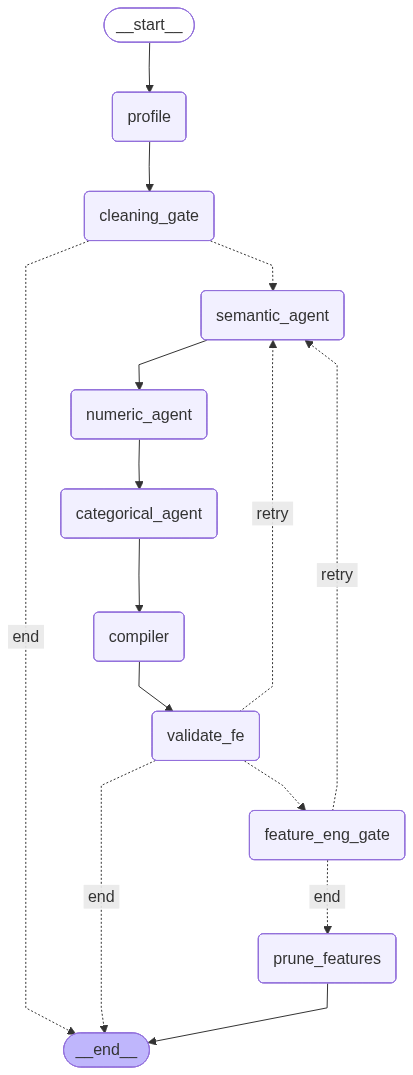

In [35]:
display(Image(pipeline.get_graph().draw_mermaid_png()))

## Extract Feature Engineering State as JSON

Extract the Feature Engineering agent's state as a JSON for the Model agent to read from.

### Inspect Feature Engineering State

In [36]:
final_state['feature_stats_report']

{'structural_overview': {'total_rows': 5493754,
  'total_columns': 51,
  'column_types': {'Start_Time_Month': 'IntegerType()',
   'Severity': 'IntegerType()',
   'Start_Lat': 'DoubleType()',
   'Start_Lng': 'DoubleType()',
   'Humidity(%)': 'DoubleType()',
   'Pressure(in)': 'DoubleType()',
   'Wind_Speed(mph)': 'DoubleType()',
   'Precipitation(in)': 'DoubleType()',
   'Crossing': 'IntegerType()',
   'Junction': 'IntegerType()',
   'Station': 'IntegerType()',
   'Stop': 'IntegerType()',
   'Traffic_Signal': 'IntegerType()',
   'Start_Time_Year': 'IntegerType()',
   'Start_Time_Day_of_Week': 'IntegerType()',
   'Start_Time_Hour': 'IntegerType()',
   'Start_Time_is_Weekend': 'IntegerType()',
   'high_severity': 'IntegerType()',
   'is_rush_hour': 'IntegerType()',
   'is_rain': 'IntegerType()',
   'is_snow': 'IntegerType()',
   'is_fog': 'IntegerType()',
   'is_overcast': 'IntegerType()',
   'is_clear': 'IntegerType()',
   'is_storm': 'IntegerType()',
   'is_drizzle': 'IntegerType()',
  

In [37]:
print(f"feature_validation_status: {final_state.get('feature_validation_status')}")
print(f"feature_validation_message: {final_state.get('feature_validation_message')}")
print(f"feature_auto_decision: {final_state.get('feature_auto_decision')}")

feature_validation_status: approved
feature_validation_message: Engineered features accepted for modeling.
feature_auto_decision: {'decision': 'accept', 'status': 'approved', 'validation_passed': True, 'semantic_flags_reviewed': 20, 'suspicious_semantic_flags': [{'target_column': 'is_sleet_or_ice', 'reason': 'true_ratio too low (0.0002) -> likely over-specific regex'}, {'target_column': 'is_parkway', 'reason': 'true_ratio too low (0.0003) -> likely over-specific regex'}, {'target_column': 'is_one_way', 'reason': 'engineered semantic flag not found in final profile'}, {'target_column': 'is_private_road', 'reason': 'true_ratio too low (0.0000) -> likely over-specific regex'}], 'warning_count': 1, 'quality_issues': [], 'reason': 'Engineered features accepted for modeling.'}


### Extract State to JSON

In [38]:
def export_state(final_state:dict, output_path: str = "state/fe_agent_state.json"):
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    """
    Extracts the necessary components from feature engineering AgentState to be read by modelling agent downstream
    """
    payload = {
        "feature_columns": final_state.get("feature_cols", []),
        "feature_stats_report": final_state.get("feature_stats_report", [])
    }

    with open(output_path, "w") as f:
        json.dump(payload, f, indent=4)
    
    print(f"Feature engineering AgentState sucessfully exported to {output_path}")
    return payload

feature_eng_json = export_state(final_state)

Feature engineering AgentState sucessfully exported to state/fe_agent_state.json


## Stop Spark

In [ ]:
spark.stop()